# Module 2: Epidemic Modeling Template

## Team Members:
Kiran Spencer, Kat Horn

## Project Title:
Modeling Disease Spread With SEIR 

## Project Goal:
This project seeks to analyze data of an unknown disease using SEIR modeling, which will then aid in the identification of the disease throughout scheduled data releases. 

## Generative AI Statement:
Generative AI was used as assistance in understanding the properties behind SEIR modeling, how to apply Euler's method using python, and making professional plots.



## 1. Data and disease background
The dataset represents the spread of a mystery infectious disease within a population of approximately 17,900 individuals, which we assume corresponds to the relevant population being modeled. The incidence of the disease refers to the number of new infections occurring each day, while prevalence refers to the total number of active cases at a given time.

The early outbreak data shows a gradual increase in reported active infections followed by rapid exponential growth, which is typical of infectious disease outbreaks when most individuals are still susceptible. According to the SEIR model prediction, the epidemic reached a peak of approximately 3,294 active cases around day 83, meaning roughly 18–22% of the population was infected simultaneously at the peak.

The economic burden of a viral outbreak can manifest as heathcare cost, institutional expenses, and the loss of productivity on the economy as those infected miss work or school and their employers cover their sick days. 

The symptoms are consistent with most upper respritory viruses, including fever, cough, fatigue, shortness of breath, body aches, and sore throat. Respiratory viruses generally infect the respiratory tract, particularly the epithelial cells lining the nose, throat, and lungs. At the cellular level, the virus typically enters host cells by binding to receptors on the cell membrane. Once inside, the virus uses the host cell’s molecular machinery to replicate its genetic material and produce viral proteins. Newly formed viral particles are then released and infect nearby cells. At the organ physiology level, infection can trigger an immune response, causing inflammation in the respiratory tract. This inflammation leads to symptoms such as coughing, mucus production, and fever. The immune system eventually clears the infection, after which individuals move into the recovered (R) category in the SEIR model.

## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

To analyze the spread of the mystery disease, we used epidemiological data analysis and mathematical modeling techniques implemented in Python.

First, we visualized the early outbreak data by plotting reported active infections versus time. This allowed us to observe the initial growth pattern of the epidemic. Because infectious diseases often grow exponentially in the early phase of an outbreak, we fitted an exponential growth curve to the early infection data using a nonlinear least squares fitting method. From the fitted growth rate, we estimated the basic reproduction number (R₀) using the relationship between the growth rate and the recovery rate.

Next, we implemented the SEIR epidemiological model, which divides the population into four compartments:

S = Succeptible 

E = Exposed 

I = Infected 

R = Recovered

The SEIR model is described by a system of differential equations representing the rates of transition between these compartments.

Because these equations cannot be easily solved analytically, we used Euler’s method, a numerical technique that approximates solutions by updating the state of the system in small time steps.

To determine realistic model parameters, we performed a grid search optimization over possible values of the transmission rate (β), incubation rate (σ), and recovery rate (γ). For each parameter combination, we simulated the SEIR model and compared the predicted infection curve to the observed data using the sum of squared errors (SSE). The parameter set that minimized the SSE was selected as the best-fit model.

Finally, the optimized model was used to predict the future course of the epidemic, including the timing and magnitude of the peak number of infections.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
Data release 1 tracks the active infections through day 45 of the mystery virus outbreak. The active infections per day appears to increase exponentially, which is appropriate for the first portion of an infectious disease outbreak.

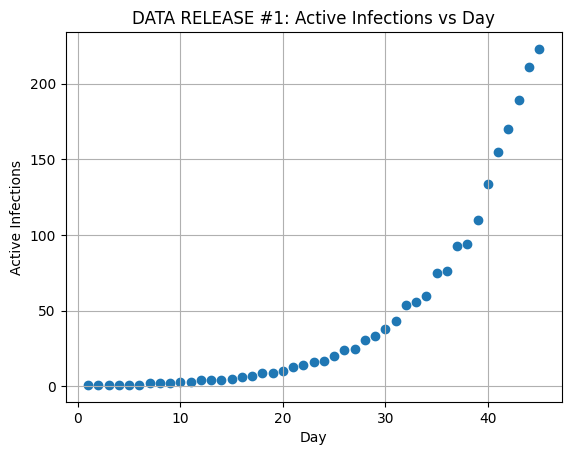

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('C:\\Users\\kiran\\Desktop\\UVA\\Classes\\Semester 4\\Computational BME\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# Plot
plt.figure() # Create a new figure
plt.scatter(data["day"], data["active reported daily cases"]) # Plot active infections vs day
plt.xlabel("Day") # Label for x-axis
plt.ylabel("Active Infections") # Label for y-axis
plt.title("DATA RELEASE #1: Active Infections vs Day") # Title for the plot
plt.grid(True) # Add a grid for better visibility
plt.show()

1. Regarding the initial infections, there is a slow but steady increasing slope, which then begins to increase more rapidly. This follows an exponential growth model which is characteristic of an outbreak where much of the population is at risk of infection. 
2. The speed of the infection can be measured by the growth of the infected population in the early stages. By fitting an this curve with an exponential equation we can estimate the initial reproduction value, R0. 
3. Information that would help determine the shape of the outbreak curve includes the transmission rate, incubation period, transmission rate, and the time of recovery. Furthermore, information such as contact patterns, disease interventions such as vaccines or quarantining would also impact the shape of the curve. 

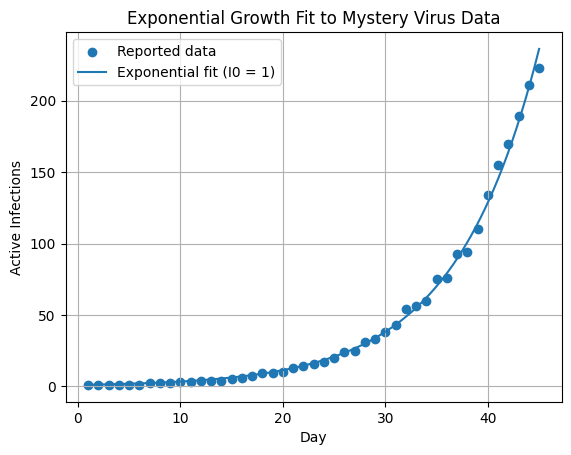

Estimated growth rate r = 0.1214 per day
Estimated R0 = 2.09


In [ ]:
import pandas as pd # import pandas for data manipulation
import matplotlib.pyplot as plt # import matplotlib for plotting
import numpy as np # import numpy for numerical operations
from scipy.optimize import curve_fit # import curve_fit for fitting the exponential growth model to the data

# Load the data
data = pd.read_csv('C:\\Users\\kiran\\Desktop\\UVA\\Classes\\Semester 4\\Computational BME\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

# Use the day number and active cases to fit an exponential growth curve to estimate R0
t = data['day'].values # time variable (day number)
I = data['active reported daily cases'].values # active infections variable (number of active cases)

# Define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data
# Initial infected population I0 = 1

initial_guess = [0.1]  # initial guess for r
params, covariance = curve_fit(exponential_growth, t, I, p0=initial_guess) # Fit the model to the data

r_est = params[0] # Extract the estimated growth rate r from the fitted parameters

# Approximate R0 using this curve fit
gamma = 1 / 9  # recovery rate based on 9-day infectious period
R0_est = 1 + r_est / gamma # R0 can be approximated as 1 + (growth rate / recovery rate) for early exponential growth phase


# Add the fit as a line on top of scatterplot
t_fit = np.linspace(min(t), max(t), 200) # Generate a range of time values for plotting the fitted curve
I_fit = exponential_growth(t_fit, r_est) # Calculate the fitted values using the estimated growth rate r_est

plt.figure() 
plt.scatter(t, I, label='Reported data') # Plot the original data points
plt.plot(t_fit, I_fit, label='Exponential fit (I0 = 1)') # Plot the fitted exponential growth curve
plt.xlabel('Day') # Label for x-axis
plt.ylabel('Active Infections') # Label for y-axis
plt.title('Exponential Growth Fit to Mystery Virus Data') # Title for the plot
plt.legend() # Add a legend to differentiate between the data points and the fitted curve
plt.grid(True) # Add a grid for better visibility
plt.show()

print(f"Estimated growth rate r = {r_est:.4f} per day")
print(f"Estimated R0 = {R0_est:.2f}")

4. We estimated R0 by fitting an exponential curve to the disease growth curve. The early slope of the exponential curve approximates the reproduction number. Using the continous growth formula with an infectious period of 9 days, the estimated growth rate was about 0.1214, and the estimated R0 value was 2.09.
5. Our estimated R0 value of 2.09 is similar to Ebola and Mpox, both of which have approximate R0 values of 2. Ebola spreads via contact with bodily fluids. While this makes the virus less transmissible, it is still incredibly dangerous with a high mortality rate. Mpox is much more transmissible, being spread by close contact and respiritory droplets. Unlike Ebola, Mpox is less dangerous once transmitted, but is suceptible to outbreak. 
6. The estimated R0​=2.09 is a reasonable approximation because it was obtained by fitting an exponential curve to the early disease growth phase, when transmission is least affected by immunity or interventions. However, the estimate assumes a constant growth rate, a fixed infectious period of 9 days, and homogeneous mixing, which are simplifications. As a result, the true R0 may differ somewhat from this value, but it is likely within the correct range of moderate transmissibility.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
Data release 2 tracks the active infections through day 70 of the mystery virus outbreak. The active infections per day still appears to increase exponentially, but the data can be used to approximate a disease curve using Euler's method and implementing an optimized grid search to find the best fit parameters with the lowest sum of squared error.

In [89]:
import pandas as pd # import pandas for data manipulation
import matplotlib.pyplot as plt # import matplotlib for plotting
import numpy as np # import numpy for numerical operations

# Load dataset
data = pd.read_csv('C:\\Users\\kiran\\Desktop\\UVA\\Classes\\Semester 4\\Computational BME\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#2.csv', parse_dates=['date'], header=0, index_col=None)

In [90]:
def run_SEIR(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N): # Function to run the SEIR model using Euler's method

    # Initialize S, E, I, and R arrays
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    # Set initial values
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    dt = 1  # timestep (1 day)

    # Euler method loop
    for t in range(len(timepoints) - 1):

        # Calculate derivatives
        dS = -beta * S[t] * I[t] / N
        dE = beta * S[t] * I[t] / N - sigma * E[t]
        dI = sigma * E[t] - gamma * I[t]
        dR = gamma * I[t]

        # Euler updates
        S[t+1] = S[t] + dS * dt
        E[t+1] = E[t] + dE * dt
        I[t+1] = I[t] + dI * dt
        R[t+1] = R[t] + dR * dt

    return S, E, I, R # Return the arrays of S, E, I, and R over time

To model the spread of the virus, we implemeneted the SEIR epidemiological model, which divides the population into four compartments:
S(t): Suspectible indivduals who can become infected
E(t): Exposed individuals who are not yet infectious
I(t): Infectious individuals who can spread the disease
R(t): Removed individuals who have recovered and are no longer infections
The total population, N, is assumed to remain constant.
The model is governed by the following differential equations:

dS/dt = (-beta)(SI)/N

dE/dt = (beta)(SI)/N - (sigma)(E)

dI/dt = (sigma)(E) - (gamma)(I)

dR/dt = (gamma)(I)

Where beta is the transmission rate, sigma is the rate at which exposed individuals become infections, and gamma is the recovery rate

Because these differential equations cannot be easily solved analytically, we approximate the solution using Euler's Method, which calculates the future value by adding the current value to the derivative multiplied by the next time step size.
The similuation begins with initial conditions:

S0 = initial susceptible population

E0 = initial exposed population

I0 = initial infected population

R0 = initial recovered population

It then iterates though each time value and updates the respective values of S, E, I, and R to estimate their function values.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [91]:
# Function to calculate the sum of squared errors between model predictions and data
def calculate_SSE(model_I, data_I):

    n = min(len(model_I), len(data_I)) # Use the minimum length to avoid index errors if model and data lengths differ

    error = model_I[:n] - data_I[:n] # Calculate the error between model predictions and data for the overlapping time points
    SSE = np.sum(error**2) # Calculate the sum of squared errors

    return SSE # Return the calculated sum of squared errors

# Grid search to find best-fitting SEIR parameters
def fit_SEIR_gridsearch(timepoints, N, S0, E0, I0, R0, data):

    data_I = data['active reported daily cases'].values # Extract the active infections data from the dataset for comparison with model predictions

    # Parameter ranges (centered around R0 ≈ 2 estimate)
    beta_range  = np.linspace(0.22, 0.33, 25)
    sigma_range = np.linspace(0.20, 0.35, 25)
    gamma_range = np.linspace(0.11, 0.15, 25)

    best_SSE = np.inf # Initialize best SSE to infinity for comparison
    best_beta = None # Initialize best beta to None
    best_sigma = None # Initialize best sigma to None
    best_gamma = None # Initialize best gamma to None

    for b in beta_range: # Iterate over the range of beta values
        for s in sigma_range: # Iterate over the range of sigma values
            for g in gamma_range: # Iterate over the range of gamma values

                S, E, I, R = run_SEIR(b, s, g, S0, E0, I0, R0, timepoints, N) # Run the SEIR model with the current set of parameters

                SSE = calculate_SSE(I, data_I) # Calculate the sum of squared errors between the model predictions and the data

                if SSE < best_SSE: # If the current SSE is better than the best SSE found so far, update the best parameters and best SSE
                    best_SSE = SSE
                    best_beta = b
                    best_sigma = s
                    best_gamma = g 

    return best_beta, best_sigma, best_gamma, best_SSE


# Set initial conditions and run grid search to fit SEIR model to data
# Population information
N = 17900 # Total population size (assumed for the region being modeled)

I0 = 1 # Initial number of infected individuals (starting with 1 infected person)
E0 = 5 # Initial number of exposed individuals (assumed to be 5 based on early growth)
R0 = 0 # Initial number of recovered individuals (starting with 0 recovered)
S0 = N - I0 - E0 - R0 # Initial number of susceptible individuals (the rest of the population)

# Timepoints matching dataset
timepoints = np.arange(0, len(data), 1)

# Run grid search
best_beta, best_sigma, best_gamma, best_SSE = fit_SEIR_gridsearch(timepoints, N, S0, E0, I0, R0, data)

print("Best beta:", best_beta) # Print the best beta value found from the grid search
print("Best sigma:", best_sigma) # Print the best sigma value found from the grid search
print("Best gamma:", best_gamma) # Print the best gamma value found from the grid search
print("Best SSE:", best_SSE) # Print the best sum of squared errors corresponding to the best parameters

print("Estimated R0 from model:", best_beta / best_gamma) # Calculate and print the estimated R0 from the best-fitting parameters

Best beta: 0.33
Best sigma: 0.24375
Best gamma: 0.11333333333333333
Best SSE: 120826.14686809502
Estimated R0 from model: 2.9117647058823533


To determine realistic values for beta, sigma, and gamma, we used a grid search optimization approach that tested multiple combinations of these parameters. For each combination, the SEIR model was simulated using Euler's method, the predicted infected population over time was compared to the actual infected data, and the sum of squared error (SSE) was calculated. The parameters that gave the lowest SSE were selected as the best fit for the dataset. In this case, the grid search optimization found the best beta, sigma, and gamma values to be 0.33, 0.24375, and 0.113, respectively, which a best SSE of 120826.

### 2e. Plot the model-predicted infections over time compared to the data.


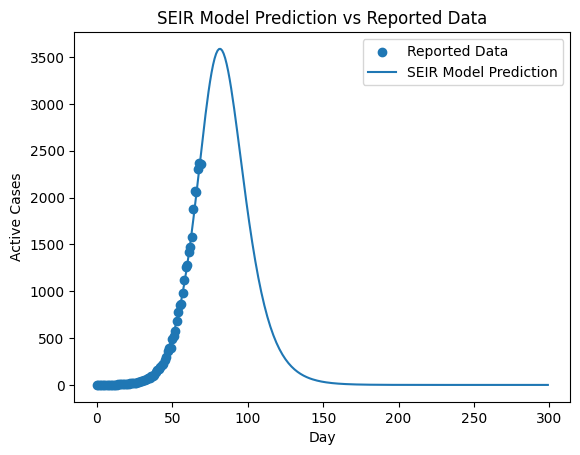

In [92]:


# We extend the simulation to 300 days so the epidemic has time to reach its peak
long_timepoints = np.arange(0, 300, 1)

# Run the SEIR model using the best parameters found from the grid search
# This returns arrays representing the number of Susceptible, Exposed,
# Infectious, and Recovered individuals at each time point
S_long, E_long, I_long, R_long = run_SEIR(
    best_beta,      # transmission rate
    best_sigma,     # rate exposed individuals become infectious
    best_gamma,     # recovery rate
    S0,             # initial susceptible population
    E0,             # initial exposed population
    I0,             # initial infected population
    R0,             # initial recovered population
    long_timepoints,# timepoints for the simulation
    N               # total population size
)


# Create a new figure
plt.figure()

# Plot the reported infection data from the dataset
plt.scatter(timepoints, data['active reported daily cases'], label="Reported Data")

# Plot the SEIR model prediction over the longer time range
plt.plot(long_timepoints, I_long, label="SEIR Model Prediction")

# Label the x-axis
plt.xlabel("Day")

# Label the y-axis
plt.ylabel("Active Cases")

# Add a title to describe the plot
plt.title("SEIR Model Prediction vs Reported Data")

# Add a legend to distinguish between data and model
plt.legend()

# Show the plot
plt.show()




This code identifies the peak of the epidemic predicted by the SEIR model. The np.max() function finds the largest value in the predicted infection array I_long, which represents the highest number of active cases. The np.argmax() function finds the day when this maximum value occurs. Finally, the code calculates the percentage of the total population infected at the peak by dividing the peak cases by the total population size.

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread

In [93]:
### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.

#Find the maximum number of infections predicted by the model
np.max # returns the largest value in the I_long array
peak_cases = np.max(I_long)

#Find the day when that maximum value occurs
np.argmax # returns the index of the largest value
peak_day = np.argmax(I_long)
# Print the predicted peak number of active infections
print("Predicted peak active cases:", peak_cases)

# Print the day when the epidemic reaches its peak
print("Predicted peak day:", peak_day)

# Calculate the percentage of the total population infected at the peak
percent_population = (peak_cases / N) * 100

# Print the percent of the population infected at the peak
print("Percent of population infected at peak:", percent_population)




Predicted peak active cases: 3586.3941647270526
Predicted peak day: 82
Percent of population infected at peak: 20.035721590653928


The SEIR model predicts that the epidemic will reach a peak of approximately 3586 active cases. This peak is expected to occur on day 82 of the outbreak. At this point, about 20% of the total population is infected simultaneously. This value is reasonable given the population size of 17,900 and the rapid growth observed in the reported case data up until day 70.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.
Data release 3 tracks the active infections through day 120 of the mystery virus outbreak. The active infections per day reach a peak, and the SEIR optimized model was modeled against the final data release.

In [94]:
import pandas as pd # import pandas for data manipulation
import matplotlib.pyplot as plt # import matplotlib for plotting
import numpy as np # import numpy for numerical operations

# Load dataset
data = pd.read_csv('C:\\Users\\kiran\\Desktop\\UVA\\Classes\\Semester 4\\Computational BME\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)

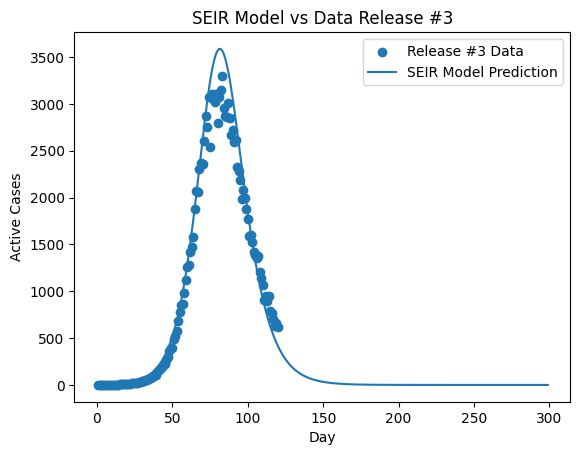

True peak cases (Release 3): 3294
True peak day (Release 3): 83
Percent relative error (peak cases): 8.876568449515867
Percent relative error (peak day): 1.2048192771084338


In [ ]:
plt.figure()

# Plot Release 3 data
plt.scatter(
    data['day'], # x-axis: day number from the dataset
    data['active reported daily cases'], # y-axis: active cases from the dataset
    label="Release #3 Data" # label for the scatter points representing the data from Release #3
)

# Plot SEIR model prediction
plt.plot(
    long_timepoints, # x-axis: time points for the model prediction
    I_long, # y-axis: predicted active cases from the SEIR model
    label="SEIR Model Prediction" # label for the line representing the model prediction
)

plt.xlabel("Day") # Label for x-axis
plt.ylabel("Active Cases") # Label for y-axis
plt.title("SEIR Model vs Data Release #3") # Title for the plot comparing the SEIR model predictions to the data from Release #3
plt.legend()

plt.show()

# True peak values from the dataset
true_peak_cases = np.max(data['active reported daily cases']) # Find the maximum number of active cases from the dataset
true_peak_day = data['day'][data['active reported daily cases'].idxmax()] # Find the day corresponding to the maximum number of active cases in the dataset

print("True peak cases (Release 3):", true_peak_cases)
print("True peak day (Release 3):", true_peak_day)

# Percent relative error for peak cases (y error)
error_cases = abs(true_peak_cases - peak_cases) / true_peak_cases * 100

# Percent relative error for peak day (x error)
error_day = abs(true_peak_day - peak_day) / true_peak_day * 100

print("Percent relative error (peak cases):", error_cases)
print("Percent relative error (peak day):", error_day)

Using our model, we predeicted that the peak number of cases would be 3586. Upon recieving the expanded data, we found the true peak to be 3294 cases, which is 8.88% lower than we predicted. Using our earlier models, we predicted the day with the peak number of cases to be 82, which was 1.2% off from the true number of day 83. Overall, these errors are relatively low given the limited data available, and the model predicted the peak day and cases relatively accurately.

There are a few possible causes for this error. In real epidemics, the transmission rate, incubation rate, and recovery rate change as the disease develops and new strains emerge. However, in our model, we assigned each of these values as constant. Second, our code did not take into account the behavior of the affected individuals. In reality, individuals may resist isolation, vaccines, and preventative measures. Our code treated each case as though the infected indivuals. We also assumed homogenous mixing, which would mean that everyone in the population would have an equal risk of getting infected. However, that is not always accurate. Last, our model was made using the early outbreak data, which models an exponential curve. However, smaller errors in the early parameter estimates can produce larger errors later in the epidemic when the model is projected forward, which likely contributed to the overestimation of the peak number of cases.

### 2h. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



### Baseline at Virginia Tech
The disease model using the best beta, sigma, and gamma was applied to Virginia Tech's student population (38,000 students) to model outbreak patterns in Blacksburg and how different interventions would reduce the number of infections over a period of time.

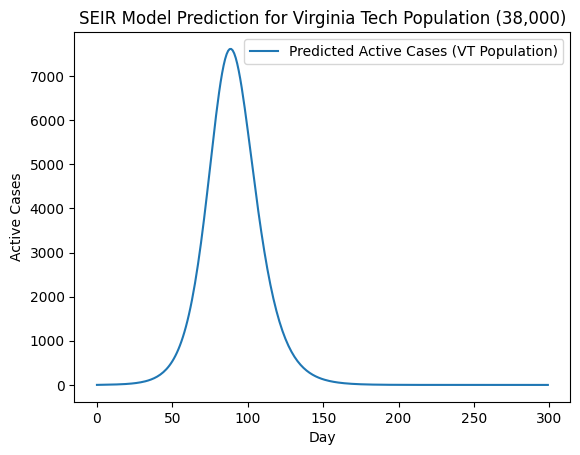

VT predicted peak cases: 7613.134117641253
VT predicted peak day: 89
Percent of VT population infected at peak: 20.034563467476982


In [ ]:
# Virginia Tech population
N_VT = 38000

# Initial conditions
I0_VT = 1
E0_VT = 5
R0_VT = 0
S0_VT = N_VT - I0_VT - E0_VT - R0_VT

# Timepoints for longer simulation
timepoints_VT = np.arange(0, 300, 1)

# Run SEIR model with same optimized parameters
S_VT, E_VT, I_VT, R_VT = run_SEIR(
    best_beta,
    best_sigma,
    best_gamma,
    S0_VT,
    E0_VT,
    I0_VT,
    R0_VT,
    timepoints_VT,
    N_VT
)

# Plot the predicted active cases for the Virginia Tech population
plt.figure()

plt.plot(timepoints_VT, I_VT, label="Predicted Active Cases (VT Population)")

plt.xlabel("Day") # Label for x-axis
plt.ylabel("Active Cases") # Label for y-axis
plt.title("SEIR Model Prediction for Virginia Tech Population (38,000)") # Title for the plot
plt.legend()

plt.show()

# Peak infections and day
VT_peak_cases = np.max(I_VT) # Find the maximum number of active cases predicted for the VT population
VT_peak_day = np.argmax(I_VT) # Find the day corresponding to the maximum number of active cases predicted for the VT population

print("VT predicted peak cases:", VT_peak_cases)
print("VT predicted peak day:", VT_peak_day)

# Percent of population infected at peak
VT_peak_percent = (VT_peak_cases / N_VT) * 100
print("Percent of VT population infected at peak:", VT_peak_percent)

At Virginia Tech, with a higher student population, the model predicted number of peak cases was much higher than the peak at the University of Virginia, at about 7613, and it occured at day 89. However, the percent infected at peak was predicted to be about the same in both univesities (20%).

### Intervention Strategy 1: Masking Mandates

One intervention strategy simulated is implementing mask mandates at day 70 with varying strengths: cloth masks at about 26.5%, surgical masks at about 40%, and N95 masks at about 70% reduced transmission rate:

#### Mask mandate SEIR simulation function

In [ ]:
def run_SEIR_mask(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N, mask_day, mask_strength): # Function to run the SEIR model with a mask mandate starting at mask_day and reducing transmission by mask_strength

    S = [S0] # Initialize the list for susceptible individuals with the initial value S0
    E = [E0] # Initialize the list for exposed individuals with the initial value E0
    I = [I0] # Initialize the list for infected individuals with the initial value I0
    R = [R0] # Initialize the list for recovered individuals with the initial value R0

    for t in range(len(timepoints)-1):

        # Apply mask mandate after mask_day
        if t >= mask_day: 
            beta_effective = beta * (1 - mask_strength)
        else:
            beta_effective = beta

        # SEIR derivatives
        dS = -beta_effective * S[t] * I[t] / N
        dE = beta_effective * S[t] * I[t] / N - sigma * E[t]
        dI = sigma * E[t] - gamma * I[t]
        dR = gamma * I[t]

        # Euler update
        S.append(S[t] + dS)
        E.append(E[t] + dE)
        I.append(I[t] + dI)
        R.append(R[t] + dR)

    return np.array(S), np.array(E), np.array(I), np.array(R)

#### Set VT population

In [ ]:
N_VT = 38000 # Total population of Virginia Tech

I0_VT = 1 # Initial infected individuals at VT
E0_VT = 5 # Initial exposed individuals at VT
R0_VT = 0 # Initial recovered individuals at VT
S0_VT = N_VT - I0_VT - E0_VT - R0_VT # Initial susceptible individuals at VT

timepoints_VT = np.arange(0, 200, 1)

#### Run baseline and mask mandate scenarios

In [ ]:
S_base, E_base, I_base, R_base = run_SEIR( 
    best_beta,
    best_sigma,
    best_gamma,
    S0_VT,
    E0_VT,
    I0_VT,
    R0_VT,
    timepoints_VT,
    N_VT
) # Run the baseline SEIR model without masks for the VT population

mask_day = 70 # Assume mask mandate starts on day 70 of the simulation

# Mask strengths
mask_265 = 0.265 # Mask strength for cloth masks (26.5% reduction in transmission)
mask_40 = 0.40 # Mask strength for surgical masks (40% reduction in transmission)
mask_70 = 0.70 # Mask strength for N95 masks (70% reduction in transmission)

S_265, E_265, I_265, R_265 = run_SEIR_mask(best_beta, best_sigma, best_gamma,
                                           S0_VT, E0_VT, I0_VT, R0_VT,
                                           timepoints_VT, N_VT,
                                           mask_day, mask_265) # Run the SEIR model with a cloth mask mandate starting at day 70

S_40, E_40, I_40, R_40 = run_SEIR_mask(best_beta, best_sigma, best_gamma,
                                       S0_VT, E0_VT, I0_VT, R0_VT,
                                       timepoints_VT, N_VT,
                                       mask_day, mask_40) # Run the SEIR model with a surgical mask mandate starting at day 70

S_70, E_70, I_70, R_70 = run_SEIR_mask(best_beta, best_sigma, best_gamma,
                                       S0_VT, E0_VT, I0_VT, R0_VT,
                                       timepoints_VT, N_VT,
                                       mask_day, mask_70) # Run the SEIR model with an N95 mask mandate starting at day 70



#### Compare baseline to mask scenarios

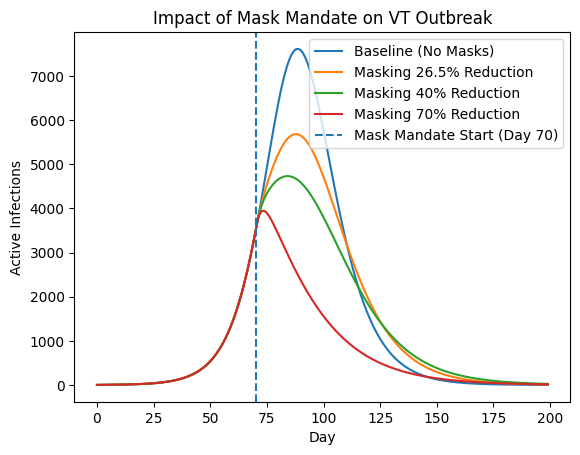

Baseline peak: 7613.134117641253 on day 89
26.5% masking peak: 5684.384559563923 on day 88
40% masking peak: 4732.400169307035 on day 84
70% masking peak: 3947.4743592487976 on day 73


In [ ]:
plt.figure()

plt.plot(timepoints_VT, I_base, label="Baseline (No Masks)") # Plot the baseline SEIR model prediction without masks for the VT population
plt.plot(timepoints_VT, I_265, label="Masking 26.5% Reduction") # Plot the SEIR model prediction with a cloth mask mandate (26.5% reduction in transmission)
plt.plot(timepoints_VT, I_40, label="Masking 40% Reduction") # Plot the SEIR model prediction with a surgical mask mandate (40% reduction in transmission)
plt.plot(timepoints_VT, I_70, label="Masking 70% Reduction") # Plot the SEIR model prediction with an N95 mask mandate (70% reduction in transmission)

plt.axvline(mask_day, linestyle='--', label="Mask Mandate Start (Day 70)") # Add a vertical dashed line to indicate when the mask mandate starts (day 70)

plt.xlabel("Day") # Label for x-axis
plt.ylabel("Active Infections") # Label for y-axis
plt.title("Impact of Mask Mandate on VT Outbreak") # Title for the plot showing the impact of different mask mandates on the predicted outbreak at Virginia Tech
plt.legend()

plt.show()

# Baseline
baseline_peak_cases = np.max(I_base) # Find the maximum number of active cases predicted for the baseline scenario without masks
baseline_peak_day = np.argmax(I_base) # Find the day corresponding to the maximum number of active cases predicted for the baseline scenario without masks

# 26.5% masking
peak_265_cases = np.max(I_265) # Find the maximum number of active cases predicted for the scenario with a cloth mask mandate (26.5% reduction in transmission)
peak_265_day = np.argmax(I_265) # Find the day corresponding to the maximum number of active cases predicted for the scenario with a cloth mask mandate (26.5% reduction in transmission)

# 40% masking
peak_40_cases = np.max(I_40) # Find the maximum number of active cases predicted for the scenario with a surgical mask mandate (40% reduction in transmission)
peak_40_day = np.argmax(I_40) # Find the day corresponding to the maximum number of active cases predicted for the scenario with a surgical mask mandate (40% reduction in transmission)

# 70% masking
peak_70_cases = np.max(I_70) # Find the maximum number of active cases predicted for the scenario with an N95 mask mandate (70% reduction in transmission)
peak_70_day = np.argmax(I_70) # Find the day corresponding to the maximum number of active cases predicted for the scenario with an N95 mask mandate (70% reduction in transmission)

print("Baseline peak:", baseline_peak_cases, "on day", baseline_peak_day)

print("26.5% masking peak:", peak_265_cases, "on day", peak_265_day)

print("40% masking peak:", peak_40_cases, "on day", peak_40_day)

print("70% masking peak:", peak_70_cases, "on day", peak_70_day)

#### Results
Implementing mask mandates at day 70 was a successful method of reducing peak cases. It also reduced the day the number of peak cases occured. As expected, the highest performing mask (N95) reduced cases the most compared to baseline, while the least performing masks (cloth, no filter) reduced cases the least compared to baseline. However, this model assumes 100% compliance from the entire VT population, which as seen during the COVID-19 pandemic, is not entirely realistic.

### Intervention Strategy 2: Vaccine Campaign
Another intervention strategy is a mass vaccine event, vaccinating 2000 susceptible students with 90% efficacy (effectively meaning 1800 susceptible students move to the recovered label). The effects of a vaccine event was tested across timeframes of when said event could happen: day 40 after the outbreak, day 70, and day 100.

#### SEIR function with vaccination event

In [ ]:
def run_SEIR_vaccine(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N, vaccine_day, vaccines, efficacy): # Function to run the SEIR model with a vaccination event on vaccine_day where a certain number of vaccines are administered with a given efficacy

    S = [S0] # Initialize the list for susceptible individuals with the initial value S0
    E = [E0] # Initialize the list for exposed individuals with the initial value E0
    I = [I0] # Initialize the list for infected individuals with the initial value I0
    R = [R0] # Initialize the list for recovered individuals with the initial value R0

    vaccinated_effective = vaccines * efficacy # Calculate the effective number of vaccinated individuals who gain immunity based on the number of vaccines administered and their efficacy

    for t in range(len(timepoints)-1):

        S_current = S[t]
        E_current = E[t]
        I_current = I[t]
        R_current = R[t]

        # Vaccination event
        if t == vaccine_day:
            vaccinated = min(vaccinated_effective, S_current)
            S_current -= vaccinated
            R_current += vaccinated

        # SEIR derivatives
        dS = -beta * S_current * I_current / N
        dE = beta * S_current * I_current / N - sigma * E_current
        dI = sigma * E_current - gamma * I_current
        dR = gamma * I_current

        # Euler update
        S.append(S_current + dS)
        E.append(E_current + dE)
        I.append(I_current + dI)
        R.append(R_current + dR)

    return np.array(S), np.array(E), np.array(I), np.array(R)

#### Run vaccination scenarios

In [ ]:
N_VT = 38000 # Total population of Virginia Tech

I0_VT = 1 # Initial infected individuals at VT
E0_VT = 5 # Initial exposed individuals at VT
R0_VT = 0 # Initial recovered individuals at VT
S0_VT = N_VT - I0_VT - E0_VT - R0_VT # Initial susceptible individuals at VT

timepoints_VT = np.arange(0, 200, 1)

vaccines = 2000 # Number of vaccines administered on the vaccination day
efficacy = 0.90 # Efficacy of the vaccine (90% reduction in susceptibility for vaccinated individuals)

# Day 40 vaccination
S_v40, E_v40, I_v40, R_v40 = run_SEIR_vaccine(
    best_beta, best_sigma, best_gamma,
    S0_VT, E0_VT, I0_VT, R0_VT,
    timepoints_VT, N_VT,
    vaccine_day=40,
    vaccines=vaccines,
    efficacy=efficacy
) # Run the SEIR model with a vaccination event on day 40 for the VT population

# Day 70 vaccination
S_v70, E_v70, I_v70, R_v70 = run_SEIR_vaccine(
    best_beta, best_sigma, best_gamma,
    S0_VT, E0_VT, I0_VT, R0_VT,
    timepoints_VT, N_VT,
    vaccine_day=70,
    vaccines=vaccines,
    efficacy=efficacy
) # Run the SEIR model with a vaccination event on day 70 for the VT population

# Day 100 vaccination
S_v100, E_v100, I_v100, R_v100 = run_SEIR_vaccine(
    best_beta, best_sigma, best_gamma,
    S0_VT, E0_VT, I0_VT, R0_VT,
    timepoints_VT, N_VT,
    vaccine_day=100,
    vaccines=vaccines,
    efficacy=efficacy
) # Run the SEIR model with a vaccination event on day 100 for the VT population

#### Plot vaccination scenarios vs baseline

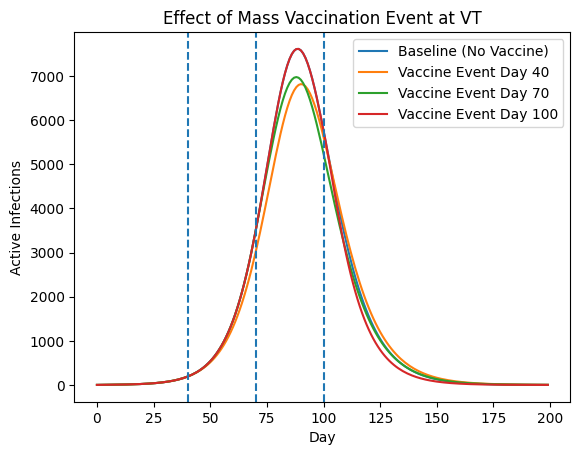

Baseline peak: 7613.134117641253 day 89
Vaccine day 40 peak: 6815.8304848147945 day 90
Vaccine day 70 peak: 6975.63765547902 day 88
Vaccine day 100 peak: 7613.134117641253 day 89


In [ ]:
plt.figure()

plt.plot(timepoints_VT, I_base, label="Baseline (No Vaccine)") # Plot the baseline SEIR model prediction without vaccination for the VT population
plt.plot(timepoints_VT, I_v40, label="Vaccine Event Day 40") # Plot the SEIR model prediction with a vaccination event on day 40 for the VT population
plt.plot(timepoints_VT, I_v70, label="Vaccine Event Day 70") # Plot the SEIR model prediction with a vaccination event on day 70 for the VT population
plt.plot(timepoints_VT, I_v100, label="Vaccine Event Day 100") # Plot the SEIR model prediction with a vaccination event on day 100 for the VT population

plt.axvline(40, linestyle='--') # Add a vertical dashed line to indicate when the vaccination event occurs on day 40
plt.axvline(70, linestyle='--') # Add a vertical dashed line to indicate when the vaccination event occurs on day 70
plt.axvline(100, linestyle='--') # Add a vertical dashed line to indicate when the vaccination event occurs on day 100

plt.xlabel("Day") # Label for x-axis
plt.ylabel("Active Infections") # Label for y-axis
plt.title("Effect of Mass Vaccination Event at VT") # Title for the plot showing the effect of mass vaccination events on the predicted outbreak at Virginia Tech
plt.legend()

plt.show()

print("Baseline peak:", np.max(I_base), "day", np.argmax(I_base)) # Print the peak number of active infections and the day it occurs for the baseline scenario without vaccination

print("Vaccine day 40 peak:", np.max(I_v40), "day", np.argmax(I_v40)) # Print the peak number of active infections and the day it occurs for the scenario with a vaccination event on day 40

print("Vaccine day 70 peak:", np.max(I_v70), "day", np.argmax(I_v70)) # Print the peak number of active infections and the day it occurs for the scenario with a vaccination event on day 70

print("Vaccine day 100 peak:", np.max(I_v100), "day", np.argmax(I_v100)) # Print the peak number of active infections and the day it occurs for the scenario with a vaccination event on day 100

#### Results
As expected, earlier vaccine rollout reduced the peak number of cases. However, vaccine rollout at day 100 saw almost no change in the infection curve model. Interestingly, earlier vaccine rollout at day 40 leads to a later peak day (90) than baseline (89) and vaccine rollout at day 70 (88). However, having enough data to have a large vaccine event is ambitious by day 40, so a day 70 vaccination event is more realistic and almost as effective at reducing peak cases.

### Intervention Strategy 3: School Closure
A final intervention strategy is a school closure at day 70, which reduces the contact rate by 80% (reduces beta to 20% of its original value). Different lengths (1 week, 2 weeks, 3 weeks) of closure will be tested, and then the contact rate will return to normal.

#### SEIR model with temporary school closure

In [ ]:
def run_SEIR_school_closure(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N, closure_day, closure_length, reduction): # Function to run the SEIR model with a school closure starting at closure_day for closure_length days, reducing transmission by reduction during that period

    S = [S0] # Initialize the list for susceptible individuals with the initial value S0
    E = [E0] # Initialize the list for exposed individuals with the initial value E0
    I = [I0] # Initialize the list for infected individuals with the initial value I0
    R = [R0] # Initialize the list for recovered individuals with the initial value R0

    for t in range(len(timepoints)-1):

        S_current = S[t]
        E_current = E[t]
        I_current = I[t]
        R_current = R[t]

        # Adjust beta during school closure
        if closure_day <= t < closure_day + closure_length:
            beta_t = beta * (1 - reduction)   # reduce beta
        else:
            beta_t = beta

        # SEIR derivatives
        dS = -beta_t * S_current * I_current / N
        dE = beta_t * S_current * I_current / N - sigma * E_current
        dI = sigma * E_current - gamma * I_current
        dR = gamma * I_current

        # Euler update
        S.append(S_current + dS)
        E.append(E_current + dE)
        I.append(I_current + dI)
        R.append(R_current + dR)

    return np.array(S), np.array(E), np.array(I), np.array(R)

#### Run closure scenarios

In [ ]:
N_VT = 38000 # Total population of Virginia Tech

I0_VT = 1 # Initial infected individuals at VT
E0_VT = 5 # Initial exposed individuals at VT
R0_VT = 0 # Initial recovered individuals at VT
S0_VT = N_VT - I0_VT - E0_VT - R0_VT # Initial susceptible individuals at VT

timepoints_VT = np.arange(0,200,1)

closure_day = 70  # Day when school closure starts
reduction = 0.80   # 80% reduction in contact rate

# 1 week closure
S_c7, E_c7, I_c7, R_c7 = run_SEIR_school_closure(
    best_beta, best_sigma, best_gamma,
    S0_VT, E0_VT, I0_VT, R0_VT,
    timepoints_VT, N_VT,
    closure_day, 7, reduction
) # Run the SEIR model with a school closure starting at day 70 for 7 days, reducing transmission by 80% during that period

# 2 week closure
S_c14, E_c14, I_c14, R_c14 = run_SEIR_school_closure(
    best_beta, best_sigma, best_gamma,
    S0_VT, E0_VT, I0_VT, R0_VT,
    timepoints_VT, N_VT,
    closure_day, 14, reduction
) # Run the SEIR model with a school closure starting at day 70 for 14 days, reducing transmission by 80% during that period

# 3 week closure
S_c21, E_c21, I_c21, R_c21 = run_SEIR_school_closure(
    best_beta, best_sigma, best_gamma,
    S0_VT, E0_VT, I0_VT, R0_VT,
    timepoints_VT, N_VT,
    closure_day, 21, reduction
) # Run the SEIR model with a school closure starting at day 70 for 21 days, reducing transmission by 80% during that period

#### Plot results vs baseline

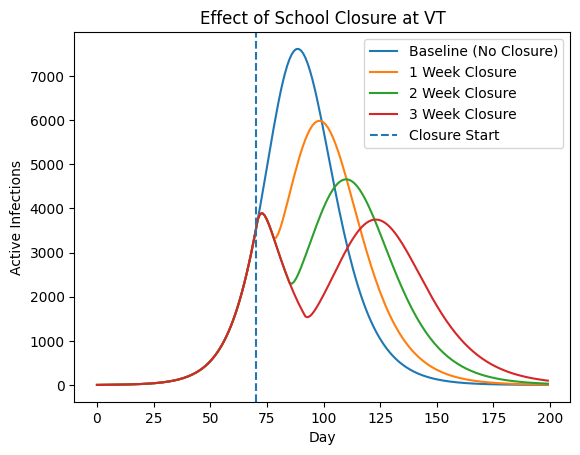

Baseline peak: 7613.134117641253 day 89
1 week closure peak: 5984.588647760676 day 98
2 week closure peak: 4659.350603114125 day 110
3 week closure peak: 3892.3157786720176 day 73


In [ ]:
plt.figure()

plt.plot(timepoints_VT, I_base, label="Baseline (No Closure)") # Plot the baseline SEIR model prediction without school closure for the VT population
plt.plot(timepoints_VT, I_c7, label="1 Week Closure") # Plot the SEIR model prediction with a school closure starting at day 70 for 7 days, reducing transmission by 80% during that period
plt.plot(timepoints_VT, I_c14, label="2 Week Closure") # Plot the SEIR model prediction with a school closure starting at day 70 for 14 days, reducing transmission by 80% during that period
plt.plot(timepoints_VT, I_c21, label="3 Week Closure") # Plot the SEIR model prediction with a school closure starting at day 70 for 21 days, reducing transmission by 80% during that period

plt.axvline(70, linestyle='--', label="Closure Start") # Add a vertical dashed line to indicate when the school closure starts (day 70)

plt.xlabel("Day") # Label for x-axis
plt.ylabel("Active Infections") # Label for y-axis
plt.title("Effect of School Closure at VT") # Title for the plot showing the effect of different lengths of school closure on the predicted outbreak at Virginia Tech
plt.legend()

plt.show()

print("Baseline peak:", np.max(I_base), "day", np.argmax(I_base)) # Print the peak number of active infections and the day it occurs for the baseline scenario without school closure

print("1 week closure peak:", np.max(I_c7), "day", np.argmax(I_c7)) # Print the peak number of active infections and the day it occurs for the scenario with a school closure starting at day 70 for 7 days, reducing transmission by 80% during that period

print("2 week closure peak:", np.max(I_c14), "day", np.argmax(I_c14)) # Print the peak number of active infections and the day it occurs for the scenario with a school closure starting at day 70 for 14 days, reducing transmission by 80% during that period

print("3 week closure peak:", np.max(I_c21), "day", np.argmax(I_c21)) # Print the peak number of active infections and the day it occurs for the scenario with a school closure starting at day 70 for 21 days, reducing transmission by 80% during that period

#### Results
School closure greatly reduced the number of peak infections, but in many cases, it prolonged when the peak day occured. In fact, it likely did not have huge results resulting the total number of infections to begin with, as once the school closure ends, people are once again exposed to each other. Additionally, since not everyone will be completely isolated from each other, the transmission rate is only reduced to 20% of its original value, before going back up after the school closure is lifted.

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*